## Cleaning the data

In [ ]:
# Install required packages
%pip install numpy pandas matplotlib seaborn
%pip install requests missingno

In [ ]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# ── 1. Load raw data ──────────────────────────────────────────────
df = pd.read_csv("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/data/raw/city_day.csv")
df = df[df['city'].str.lower() == 'kolkata'].copy()

weather = pd.read_csv("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/data/raw/weather_durgapur_raw.csv")

# Standardize column name from 'date' to 'Date'
df.rename(columns={'date': 'Date'}, inplace=True)

In [78]:
# ── 2. Parse dates ────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
weather['Date'] = pd.to_datetime(weather['Date'])

=== MISSING VALUE SUMMARY ===
city            0
Date            0
pm25            0
pm10            0
no2             0
so2             0
co              0
o3              0
aqi             0
aqi_category    0
dtype: int64

Missing AQI: 0 / 3287 rows (0.0%)


C:\Users\Rahul Nag\AppData\Local\Temp\ipykernel_22348\2756374232.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


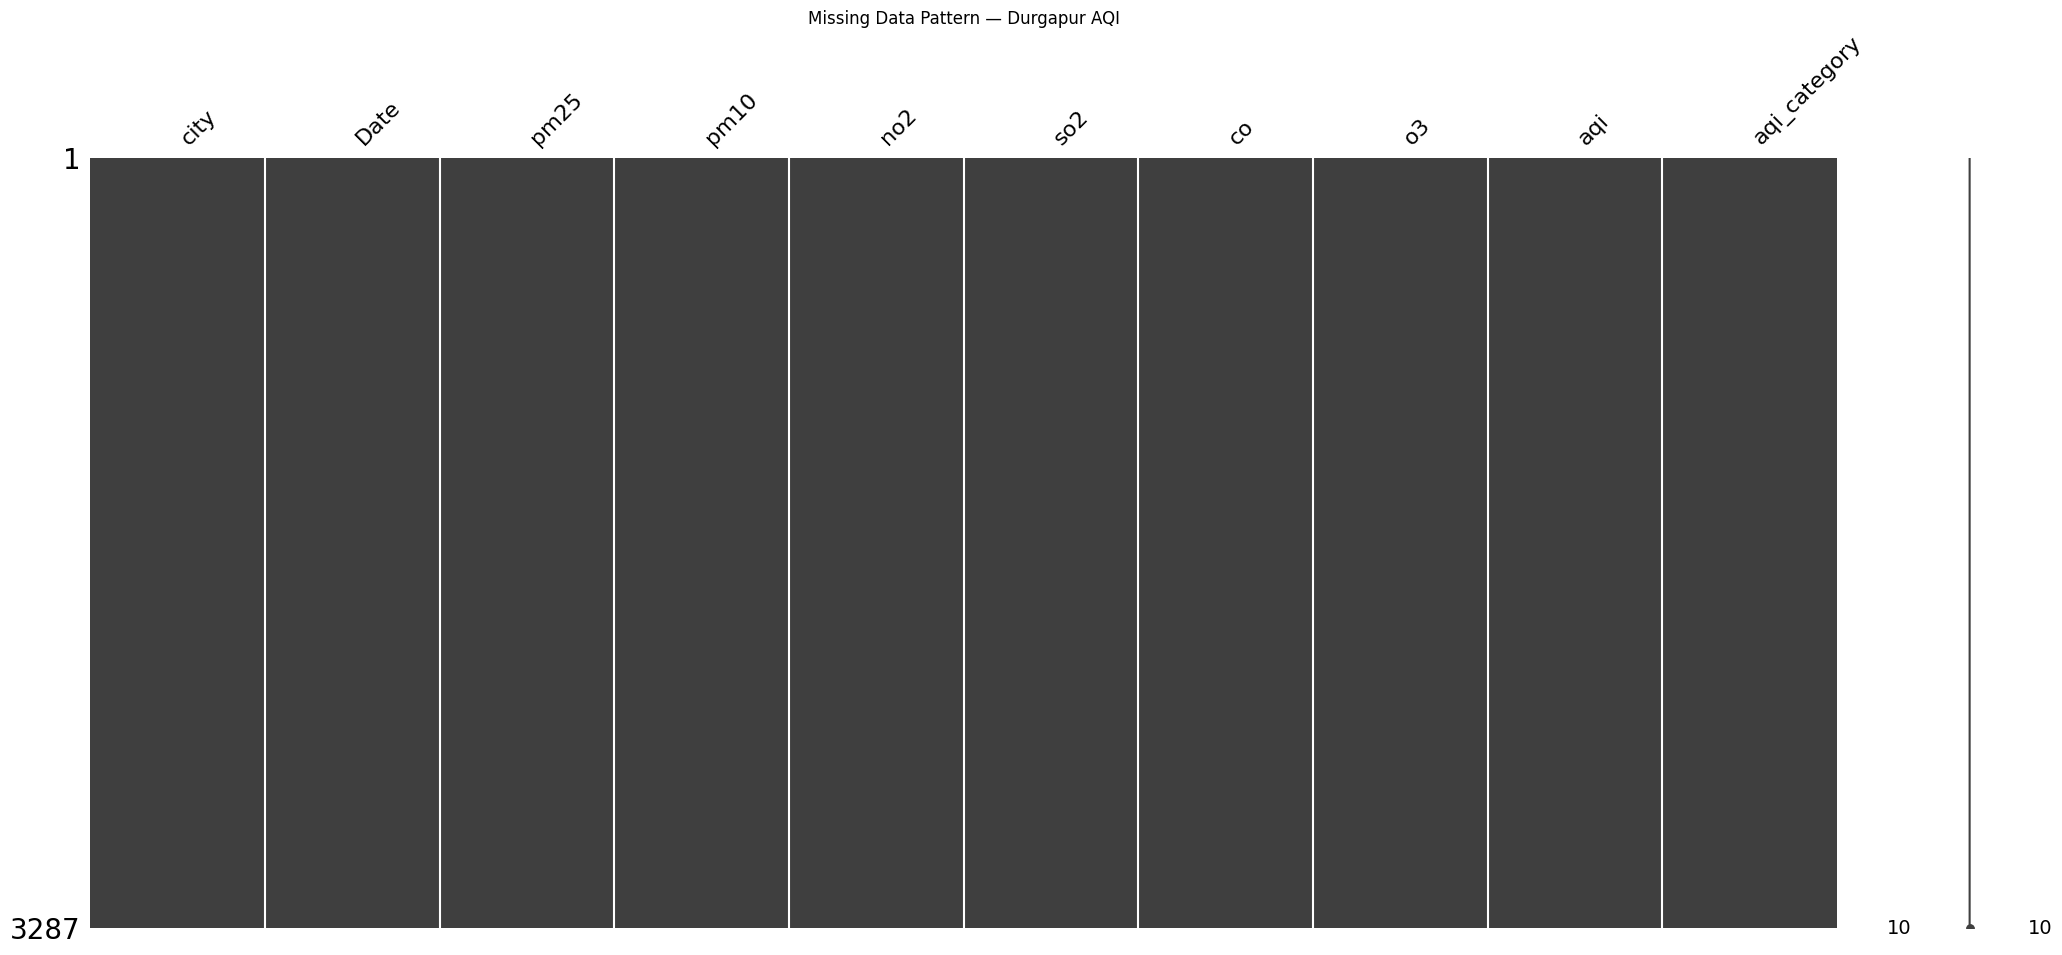

In [79]:
# ── 3. Check missing values ───────────────────────────────────────
print("=== MISSING VALUE SUMMARY ===")
print(df.isnull().sum())
print(f"\nMissing AQI: {df['aqi'].isnull().sum()} / {len(df)} rows ({df['aqi'].isnull().mean()*100:.1f}%)")


# Visualize missing data pattern
msno.matrix(df)
plt.title("Missing Data Pattern — Durgapur AQI")
plt.tight_layout()
plt.savefig("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/reports/missing_data_pattern.png", dpi=150)
plt.show()

In [ ]:
# ── 4. Handle missing values ────────────────────────────────────── # optional
# Strategy: Forward-fill short gaps (≤3 days), drop longer gaps

# Sort by date first
df = df.sort_values('Date').reset_index(drop=True)

# Forward fill pollutants (max 3 consecutive days)
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 
                  'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

for col in pollutant_cols:
    if col in df.columns:
        df[col] = df[col].fillna(method='ffill', limit=3)

# Drop rows where AQI is still missing after fill
df_clean = df.dropna(subset=['AQI']).copy()
print(f"\nRows after cleaning: {len(df_clean)} (removed {len(df) - len(df_clean)})")

In [80]:
# ── 5. Remove duplicates ──────────────────────────────────────────
df_clean = df_clean.drop_duplicates(subset=['Date'])
print(f"After dedup: {len(df_clean)} rows")

After dedup: 3287 rows


In [81]:
# ── 6. Outlier detection ──────────────────────────────────────────
# AQI above 500 is impossible on CPCB scale; flag as suspicious
df_clean['aqi_outlier'] = df_clean['aqi'] > 500

# Use IQR method for pollutants
def flag_iqr_outliers(series, factor=3):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - factor * IQR) | (series > Q3 + factor * IQR)

for col in ['PM2.5', 'PM10']:
    if col in df_clean.columns:
        df_clean[f'{col.lower().replace(".", "")}_outlier'] = flag_iqr_outliers(df_clean[col])

# Don't drop outliers — they are real events! Flag them for analysis.
print(f"\nSuspicious AQI > 500: {df_clean['aqi_outlier'].sum()} rows")


Suspicious AQI > 500: 0 rows


In [82]:
# ── 7. Add categorical AQI bucket ─────────────────────────────────
def aqi_category(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Satisfactory"
    elif aqi <= 200: return "Moderate"
    elif aqi <= 300: return "Poor"
    elif aqi <= 400: return "Very Poor"
    else: return "Severe"

df_clean['AQI_Category'] = df_clean['aqi'].apply(aqi_category)

In [ ]:
# ── 8. Merge with weather data ────────────────────────────────────
# Filter AQI data to match weather date range
df_clean = df_clean[df_clean['Date'] >= weather['Date'].min()]


# Use INNER join to keep only overlapping dates
df_merged = pd.merge(df_clean, weather, on='Date', how='inner')

print(f"\nAfter merging with weather: {len(df_merged)} rows")
print(df_merged.dtypes)


After merging with weather: 1461 rows
city                          object
date                  datetime64[ns]
pm25                         float64
pm10                         float64
no2                          float64
so2                          float64
co                           float64
o3                           float64
aqi                            int64
aqi_category                  object
Date                  datetime64[ns]
aqi_outlier                     bool
AQI Category                  object
AQI_Category                  object
temperature_2m_max           float64
temperature_2m_min           float64
windspeed_10m_max            float64
precipitation_sum            float64
dtype: object


In [ ]:
# Here, we need to perform data cleaning again as the 'aqi category', and 'date' column has occured multiple times
# If they look identical, compare them properly:
print((df_merged['AQI_Category'] == df_merged['AQI Category']).all())
print((df_merged['AQI_Category'] == df_merged['aqi_category']).all())
print((df_merged['date'] == df_merged['Date']).all())

True


In [ ]:
# Now, drop the duplicate columns
df_merged.drop(columns=['AQI Category', 'aqi_category'], inplace=True)
df_merged.drop(columns=['date'], inplace=True)

In [ ]:
# Verify that it doesn't have any duplicate columns
print(df_merged.dtypes)

city                          object
pm25                         float64
pm10                         float64
no2                          float64
so2                          float64
co                           float64
o3                           float64
aqi                            int64
Date                  datetime64[ns]
aqi_outlier                     bool
AQI_Category                  object
temperature_2m_max           float64
temperature_2m_min           float64
windspeed_10m_max            float64
precipitation_sum            float64
dtype: object


In [99]:
# ── 9. Save cleaned dataset ───────────────────────────────────────
df_merged.to_csv("C:/Users/Rahul Nag/Projects/self/durgapur-aqi-analytics/data/processed/aqi_cleaned.csv", index=False)
print("\n Cleaned dataset saved to data/processed/aqi_cleaned.csv")
print(df_merged.describe())


 Cleaned dataset saved to data/processed/aqi_cleaned.csv
              pm25         pm10          no2          so2           co  \
count  1461.000000  1461.000000  1461.000000  1461.000000  1461.000000   
mean     80.302916   130.085991    40.206380    11.972308     0.798377   
min       5.000000    15.583795     5.000000     2.000000     0.100000   
25%      52.537471    99.908656    29.949403     8.438532     0.602144   
50%      80.176062   127.831031    40.036157    11.813860     0.792919   
75%     107.947205   161.221558    50.264537    15.562307     0.995029   
max     197.338084   262.875002    87.583702    26.414987     1.703123   
std      39.543971    43.633960    14.848515     4.886115     0.301590   

                o3          aqi                 Date  temperature_2m_max  \
count  1461.000000  1461.000000                 1461         1461.000000   
mean     49.877592    87.691307  2021-12-31 00:00:00           30.986995   
min      10.000000    16.000000  2020-01-01 00: